In [1]:
# K-means Enhanced BM25 Information Retrieval System
# This notebook implements BM25 with K-means clustering for document retrieval on Cranfield dataset

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from collections import defaultdict, Counter
import ir_datasets
import math
import warnings
warnings.filterwarnings('ignore')

# BM25 implementation library
from rank_bm25 import BM25Okapi

# Text preprocessing libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import re

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Load Cranfield dataset using ir_datasets
print("Loading Cranfield dataset...")
dataset = ir_datasets.load("cranfield")

# Extract documents and queries
docs = list(dataset.docs_iter())
queries = list(dataset.queries_iter())
qrels = list(dataset.qrels_iter())

print(f"Dataset loaded successfully!")
print(f"Number of documents: {len(docs)}")
print(f"Number of queries: {len(queries)}")
print(f"Number of relevance judgments: {len(qrels)}")

# Display sample document
print("\nSample document:")
print(f"Doc ID: {docs[0].doc_id}")
print(f"Title: {docs[0].title}")
print(f"Text: {docs[0].text[:200]}...")

# Display sample query
print("\nSample query:")
print(f"Query ID: {queries[0].query_id}")
print(f"Text: {queries[0].text}")


Loading Cranfield dataset...
Dataset loaded successfully!
Number of documents: 1400
Number of queries: 225
Number of relevance judgments: 1837

Sample document:
Doc ID: 1
Title: experimental investigation of the aerodynamics of a
wing in a slipstream .
Text: experimental investigation of the aerodynamics of a
wing in a slipstream .
  an experimental study of a wing in a propeller slipstream was
made in order to determine the spanwise distribution of the l...

Sample query:
Query ID: 1
Text: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .


In [3]:
# Text preprocessing function
def preprocess_text(text):
    """
    Preprocess text by:
    - Converting to lowercase
    - Removing special characters and numbers
    - Tokenizing
    - Removing stopwords
    - Stemming
    """
    if not text:
        return []
    
    # Convert to lowercase and remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(token) for token in tokens]
    
    return tokens

# Preprocess documents
print("Preprocessing documents...")
processed_docs = []
doc_ids = []

for doc in docs:
    # Combine title and text for better representation
    full_text = f"{doc.title} {doc.text}" if doc.title else doc.text
    processed_text = preprocess_text(full_text)
    processed_docs.append(processed_text)
    doc_ids.append(doc.doc_id)

# Preprocess queries
print("Preprocessing queries...")
processed_queries = []
query_ids = []

for query in queries:
    processed_query = preprocess_text(query.text)
    processed_queries.append(processed_query)
    query_ids.append(query.query_id)

print(f"Preprocessing completed!")
print(f"Sample processed document: {processed_docs[0][:10]}")
print(f"Sample processed query: {processed_queries[0]}")


Preprocessing documents...
Preprocessing queries...
Preprocessing completed!
Sample processed document: ['experiment', 'investig', 'aerodynam', 'wing', 'slipstream', 'experiment', 'investig', 'aerodynam', 'wing', 'slipstream']
Sample processed query: ['similar', 'law', 'must', 'obey', 'construct', 'aeroelast', 'model', 'heat', 'high', 'speed', 'aircraft']


In [4]:
# Initialize BM25 model using the library
print("Initializing BM25 model...")

# Filter out empty documents
non_empty_docs = [doc for doc in processed_docs if doc]
non_empty_doc_ids = [doc_ids[i] for i, doc in enumerate(processed_docs) if doc]

print(f"Documents after filtering empty ones: {len(non_empty_docs)}")

# Initialize BM25Okapi model
bm25 = BM25Okapi(non_empty_docs)

print("BM25 model initialized successfully!")

# Create document-id mapping for easy lookup
doc_id_to_index = {doc_id: i for i, doc_id in enumerate(non_empty_doc_ids)}
index_to_doc_id = {i: doc_id for i, doc_id in enumerate(non_empty_doc_ids)}

print("Document indexing completed!")


Initializing BM25 model...
Documents after filtering empty ones: 1398
BM25 model initialized successfully!
Document indexing completed!


In [5]:
# Create TF-IDF vectors for K-means clustering
print("Creating TF-IDF vectors for K-means clustering...")

# Prepare documents for TF-IDF (convert tokens back to strings)
doc_texts = [' '.join(doc) for doc in non_empty_docs]

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Limit features for computational efficiency
    min_df=2,          # Ignore terms that appear in fewer than 2 documents
    max_df=0.8,        # Ignore terms that appear in more than 80% of documents
    ngram_range=(1, 2) # Include unigrams and bigrams
)

# Fit and transform documents
tfidf_matrix = tfidf_vectorizer.fit_transform(doc_texts)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

# Convert to dense array for clustering (if memory allows)
if tfidf_matrix.shape[0] * tfidf_matrix.shape[1] < 1000000:  # Avoid memory issues
    tfidf_dense = tfidf_matrix.toarray()
    print("Converted to dense matrix for clustering")
else:
    tfidf_dense = tfidf_matrix  # Keep sparse
    print("Using sparse matrix for clustering")


Creating TF-IDF vectors for K-means clustering...
TF-IDF matrix shape: (1398, 1000)
Number of features: 1000
Using sparse matrix for clustering


Finding optimal number of clusters...
Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...
Testing k=11...
Testing k=12...
Testing k=13...
Testing k=14...
Testing k=15...
Testing k=16...
Testing k=17...
Testing k=18...
Testing k=19...
Testing k=20...


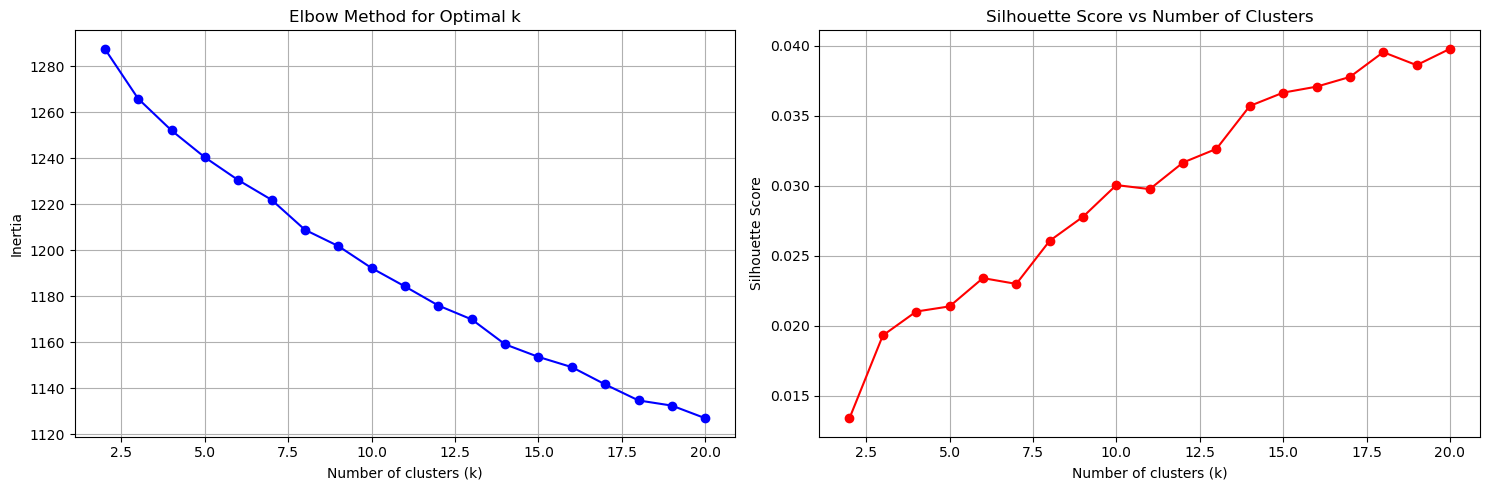

Optimal number of clusters based on silhouette score: 20
Best silhouette score: 0.040


In [6]:
# Determine optimal number of clusters using elbow method and silhouette score
print("Finding optimal number of clusters...")

# Test different numbers of clusters
k_range = range(2, min(21, len(non_empty_docs)//10))  # Reasonable range
inertias = []
silhouette_scores = []

for k in k_range:
    print(f"Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(tfidf_dense)
    
    # Calculate inertia (within-cluster sum of squares)
    inertias.append(kmeans.inertia_)
    
    # Calculate silhouette score
    if len(set(cluster_labels)) > 1:  # Need at least 2 clusters for silhouette score
        sil_score = silhouette_score(tfidf_dense, cluster_labels)
        silhouette_scores.append(sil_score)
    else:
        silhouette_scores.append(0)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

# Silhouette score plot
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs Number of Clusters')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Find optimal k based on silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")


In [7]:
# Apply K-means clustering with optimal number of clusters
print(f"Applying K-means clustering with k={optimal_k}...")

# Perform final clustering
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(tfidf_dense)

# Add cluster information to documents
doc_clusters = {}
for i, doc_id in enumerate(non_empty_doc_ids):
    doc_clusters[doc_id] = cluster_labels[i]

print(f"Clustering completed!")
print(f"Cluster distribution:")
cluster_counts = Counter(cluster_labels)
for cluster_id, count in sorted(cluster_counts.items()):
    print(f"  Cluster {cluster_id}: {count} documents")

# Analyze clusters - find most representative terms for each cluster
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop terms for each cluster:")

for i in range(optimal_k):
    # Get documents in this cluster
    cluster_docs_indices = [idx for idx, label in enumerate(cluster_labels) if label == i]
    
    # Calculate mean TF-IDF scores for this cluster
    if isinstance(tfidf_dense, np.ndarray):
        cluster_center = np.mean(tfidf_dense[cluster_docs_indices], axis=0)
    else:
        cluster_center = np.mean(tfidf_dense[cluster_docs_indices].toarray(), axis=0)
    
    # Get top terms
    top_indices = cluster_center.argsort()[-10:][::-1]
    top_terms = [feature_names[idx] for idx in top_indices]
    
    print(f"Cluster {i}: {', '.join(top_terms)}")


Applying K-means clustering with k=20...
Clustering completed!
Cluster distribution:
  Cluster 0: 51 documents
  Cluster 1: 47 documents
  Cluster 2: 43 documents
  Cluster 3: 207 documents
  Cluster 4: 120 documents
  Cluster 5: 27 documents
  Cluster 6: 79 documents
  Cluster 7: 80 documents
  Cluster 8: 86 documents
  Cluster 9: 46 documents
  Cluster 10: 26 documents
  Cluster 11: 43 documents
  Cluster 12: 56 documents
  Cluster 13: 134 documents
  Cluster 14: 81 documents
  Cluster 15: 51 documents
  Cluster 16: 44 documents
  Cluster 17: 29 documents
  Cluster 18: 92 documents
  Cluster 19: 56 documents

Top terms for each cluster:
Cluster 0: cone, angl, angl attack, attack, pressur, number, mach, mach number, degre, blunt
Cluster 1: cylind, circular cylind, circular, buckl, compress, axial, axial compress, bend, pressur, flow
Cluster 2: inject, nozzl, boundari, boundari layer, layer, ga, mass, mass transfer, wall, transfer
Cluster 3: flow, tube, compressor, solut, equat, pressu

In [8]:
# Enhanced BM25 retrieval with K-means cluster filtering
def enhanced_bm25_search(query_text, top_k=10, use_clustering=True, target_cluster=None):
    """
    Enhanced BM25 search that can optionally filter by clusters
    
    Args:
        query_text: Query string
        top_k: Number of top documents to return
        use_clustering: Whether to use cluster information
        target_cluster: Specific cluster to search in (if None, search all)
    
    Returns:
        List of (doc_id, score, cluster) tuples
    """
    # Preprocess query
    processed_query = preprocess_text(query_text)
    
    if not processed_query:
        return []
    
    # Get BM25 scores for all documents
    doc_scores = bm25.get_scores(processed_query)
    
    # Create results list
    results = []
    for i, score in enumerate(doc_scores):
        doc_id = non_empty_doc_ids[i]
        cluster = doc_clusters.get(doc_id, -1)
        
        # Filter by cluster if specified
        if target_cluster is not None and cluster != target_cluster:
            continue
            
        results.append((doc_id, score, cluster))
    
    # Sort by score and return top-k
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_k]

# Test the enhanced search
test_query = "aerodynamic flow wing design"
print(f"Testing enhanced BM25 search with query: '{test_query}'")

# Standard BM25 search
print("\n=== Standard BM25 Results ===")
standard_results = enhanced_bm25_search(test_query, top_k=10, use_clustering=False)
for i, (doc_id, score, cluster) in enumerate(standard_results):
    print(f"{i+1}. Doc {doc_id} (Cluster {cluster}): {score:.4f}")

# Cluster-aware analysis
print(f"\n=== Cluster Distribution in Results ===")
cluster_distribution = Counter([cluster for _, _, cluster in standard_results])
for cluster_id, count in sorted(cluster_distribution.items()):
    print(f"Cluster {cluster_id}: {count} documents")

# Search within most relevant cluster
if cluster_distribution:
    most_common_cluster = cluster_distribution.most_common(1)[0][0]
    print(f"\n=== Results from Most Relevant Cluster ({most_common_cluster}) ===")
    cluster_results = enhanced_bm25_search(test_query, top_k=10, target_cluster=most_common_cluster)
    for i, (doc_id, score, cluster) in enumerate(cluster_results):
        print(f"{i+1}. Doc {doc_id}: {score:.4f}")


Testing enhanced BM25 search with query: 'aerodynamic flow wing design'

=== Standard BM25 Results ===
1. Doc 415 (Cluster 4): 11.9615
2. Doc 612 (Cluster 4): 9.4522
3. Doc 749 (Cluster 4): 9.1040
4. Doc 592 (Cluster 3): 9.0394
5. Doc 1334 (Cluster 4): 8.7615
6. Doc 632 (Cluster 4): 8.5292
7. Doc 748 (Cluster 4): 8.5225
8. Doc 712 (Cluster 4): 8.4705
9. Doc 921 (Cluster 4): 8.2357
10. Doc 1332 (Cluster 4): 8.2149

=== Cluster Distribution in Results ===
Cluster 3: 1 documents
Cluster 4: 9 documents

=== Results from Most Relevant Cluster (4) ===
1. Doc 415: 11.9615
2. Doc 612: 9.4522
3. Doc 749: 9.1040
4. Doc 1334: 8.7615
5. Doc 632: 8.5292
6. Doc 748: 8.5225
7. Doc 712: 8.4705
8. Doc 921: 8.2357
9. Doc 1332: 8.2149
10. Doc 287: 7.9437


In [9]:
# Evaluation on Cranfield dataset
def evaluate_system(use_clustering=False, target_cluster=None):
    """
    Evaluate the BM25 system using Cranfield relevance judgments
    
    Args:
        use_clustering: Whether to use cluster filtering
        target_cluster: Specific cluster to search in
    
    Returns:
        Dictionary with evaluation metrics
    """
    # Prepare relevance judgments
    relevance_dict = defaultdict(set)
    for qrel in qrels:
        if qrel.relevance > 0:  # Consider only relevant documents
            relevance_dict[qrel.query_id].add(qrel.doc_id)
    
    # Evaluation metrics
    precision_scores = []
    recall_scores = []
    f1_scores = []
    map_scores = []
    
    print(f"Evaluating system on {len(relevance_dict)} queries...")
    
    for i, query in enumerate(queries):
        if query.query_id not in relevance_dict:
            continue
            
        # Get relevant documents for this query
        relevant_docs = relevance_dict[query.query_id]
        
        # Search using our system
        if use_clustering:
            results = enhanced_bm25_search(query.text, top_k=100, target_cluster=target_cluster)
        else:
            results = enhanced_bm25_search(query.text, top_k=100, use_clustering=False)
        
        retrieved_docs = [doc_id for doc_id, _, _ in results]
        
        if not retrieved_docs:
            precision_scores.append(0)
            recall_scores.append(0)
            f1_scores.append(0)
            map_scores.append(0)
            continue
        
        # Calculate precision and recall at different cutoffs
        precisions_at_k = []
        for k in range(1, min(len(retrieved_docs) + 1, 101)):
            retrieved_at_k = set(retrieved_docs[:k])
            relevant_retrieved = retrieved_at_k.intersection(relevant_docs)
            
            precision_at_k = len(relevant_retrieved) / k if k > 0 else 0
            precisions_at_k.append(precision_at_k)
        
        # Overall metrics
        retrieved_set = set(retrieved_docs)
        relevant_retrieved = retrieved_set.intersection(relevant_docs)
        
        precision = len(relevant_retrieved) / len(retrieved_set) if retrieved_set else 0
        recall = len(relevant_retrieved) / len(relevant_docs) if relevant_docs else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        # Average Precision
        avg_precision = np.mean(precisions_at_k) if precisions_at_k else 0
        
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        map_scores.append(avg_precision)
    
    # Calculate overall metrics
    metrics = {
        'mean_precision': np.mean(precision_scores),
        'mean_recall': np.mean(recall_scores),
        'mean_f1': np.mean(f1_scores),
        'map': np.mean(map_scores),  # Mean Average Precision
        'num_queries': len(precision_scores)
    }
    
    return metrics

# Evaluate standard BM25
print("=== Evaluating Standard BM25 ===")
standard_metrics = evaluate_system(use_clustering=False)
print(f"Mean Precision: {standard_metrics['mean_precision']:.4f}")
print(f"Mean Recall: {standard_metrics['mean_recall']:.4f}")
print(f"Mean F1-Score: {standard_metrics['mean_f1']:.4f}")
print(f"Mean Average Precision (MAP): {standard_metrics['map']:.4f}")
print(f"Number of queries evaluated: {standard_metrics['num_queries']}")

# Evaluate cluster-based approach for each cluster
print("\n=== Evaluating Cluster-based BM25 ===")
cluster_metrics = {}
for cluster_id in range(optimal_k):
    print(f"\nCluster {cluster_id}:")
    metrics = evaluate_system(use_clustering=True, target_cluster=cluster_id)
    cluster_metrics[cluster_id] = metrics
    print(f"  Mean Precision: {metrics['mean_precision']:.4f}")
    print(f"  Mean Recall: {metrics['mean_recall']:.4f}")
    print(f"  Mean F1-Score: {metrics['mean_f1']:.4f}")
    print(f"  MAP: {metrics['map']:.4f}")
    print(f"  Queries: {metrics['num_queries']}")


=== Evaluating Standard BM25 ===
Evaluating system on 225 queries...
Mean Precision: 0.0496
Mean Recall: 0.7440
Mean F1-Score: 0.0903
Mean Average Precision (MAP): 0.1150
Number of queries evaluated: 225

=== Evaluating Cluster-based BM25 ===

Cluster 0:
Evaluating system on 225 queries...
  Mean Precision: 0.0059
  Mean Recall: 0.0402
  Mean F1-Score: 0.0097
  MAP: 0.0112
  Queries: 225

Cluster 1:
Evaluating system on 225 queries...
  Mean Precision: 0.0064
  Mean Recall: 0.0499
  Mean F1-Score: 0.0110
  MAP: 0.0169
  Queries: 225

Cluster 2:
Evaluating system on 225 queries...
  Mean Precision: 0.0028
  Mean Recall: 0.0138
  Mean F1-Score: 0.0044
  MAP: 0.0067
  Queries: 225

Cluster 3:
Evaluating system on 225 queries...
  Mean Precision: 0.0053
  Mean Recall: 0.1200
  Mean F1-Score: 0.0100
  MAP: 0.0166
  Queries: 225

Cluster 4:
Evaluating system on 225 queries...
  Mean Precision: 0.0055
  Mean Recall: 0.0746
  Mean F1-Score: 0.0098
  MAP: 0.0132
  Queries: 225

Cluster 5:
Evalu

Creating visualizations...


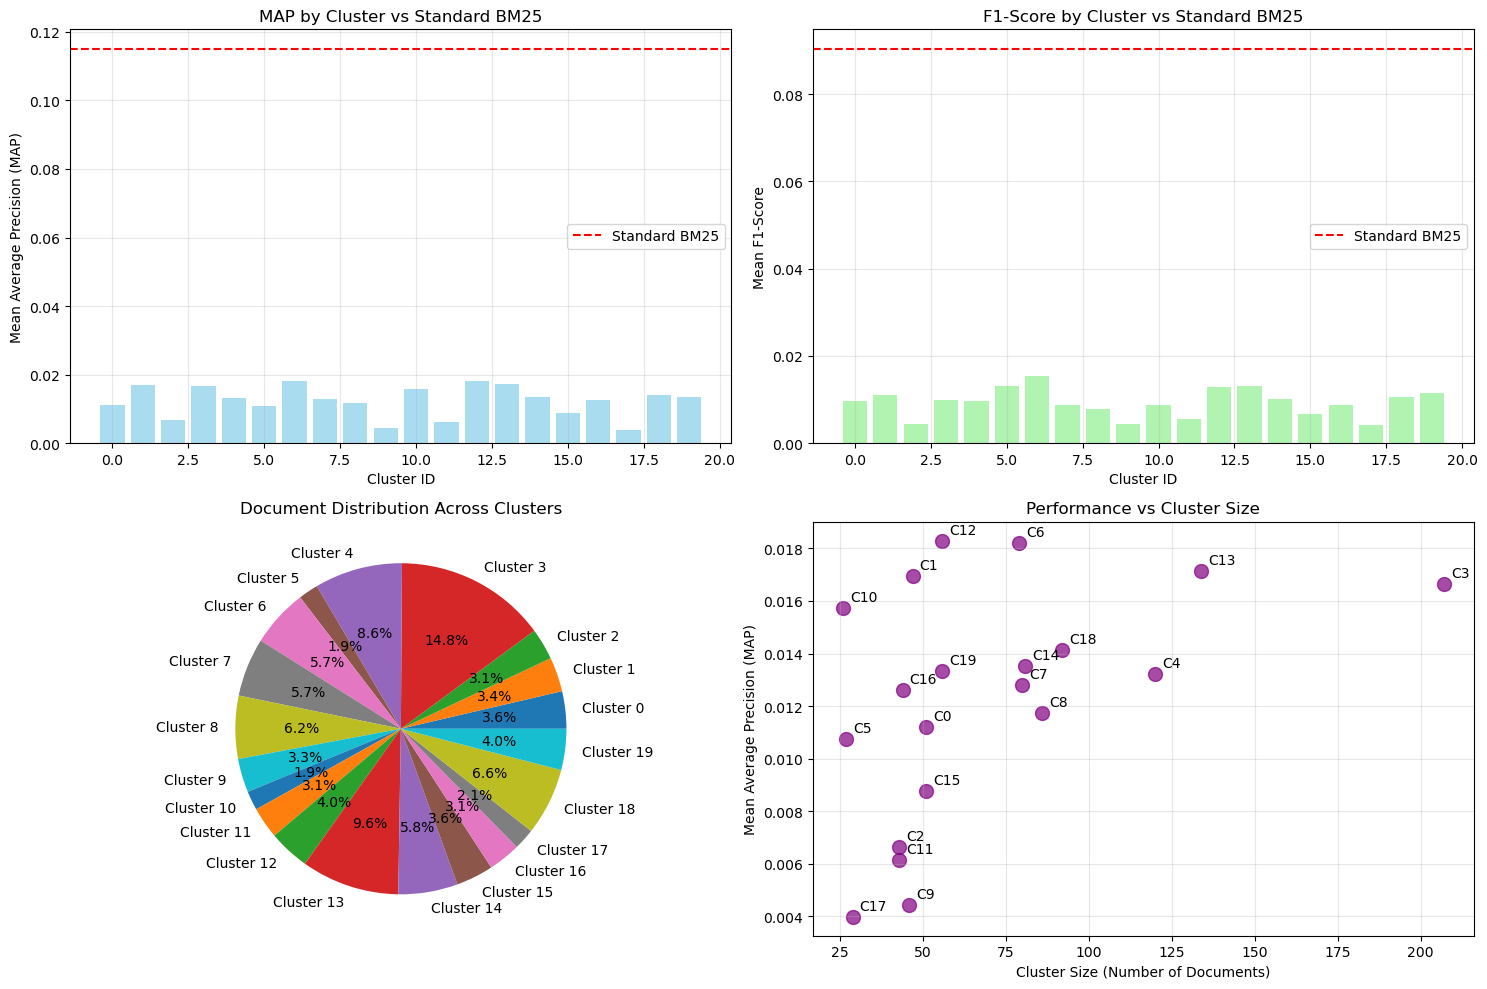


Creating cluster visualization...


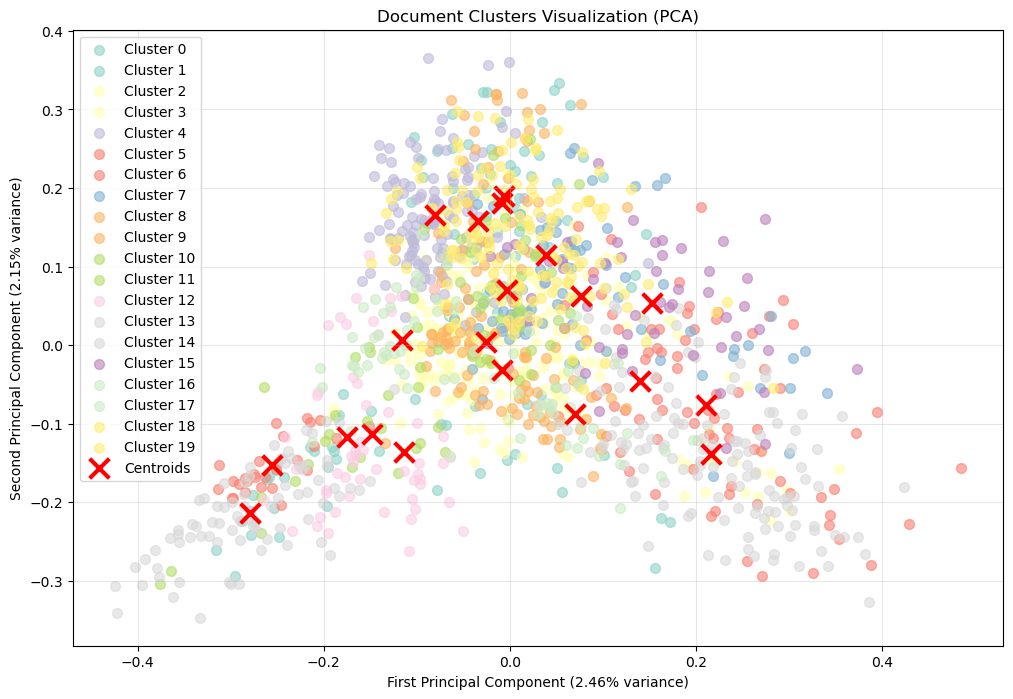

Total explained variance by first 2 components: 4.61%


In [10]:
# Visualization of results
print("Creating visualizations...")

# 1. Cluster performance comparison
cluster_ids = list(cluster_metrics.keys())
cluster_maps = [cluster_metrics[cid]['map'] for cid in cluster_ids]
cluster_f1s = [cluster_metrics[cid]['mean_f1'] for cid in cluster_ids]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# MAP comparison
ax1.bar(cluster_ids, cluster_maps, alpha=0.7, color='skyblue')
ax1.axhline(y=standard_metrics['map'], color='red', linestyle='--', label='Standard BM25')
ax1.set_xlabel('Cluster ID')
ax1.set_ylabel('Mean Average Precision (MAP)')
ax1.set_title('MAP by Cluster vs Standard BM25')
ax1.legend()
ax1.grid(True, alpha=0.3)

# F1-Score comparison
ax2.bar(cluster_ids, cluster_f1s, alpha=0.7, color='lightgreen')
ax2.axhline(y=standard_metrics['mean_f1'], color='red', linestyle='--', label='Standard BM25')
ax2.set_xlabel('Cluster ID')
ax2.set_ylabel('Mean F1-Score')
ax2.set_title('F1-Score by Cluster vs Standard BM25')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Cluster size distribution
cluster_sizes = [cluster_counts[cid] for cid in cluster_ids]
ax3.pie(cluster_sizes, labels=[f'Cluster {cid}' for cid in cluster_ids], autopct='%1.1f%%')
ax3.set_title('Document Distribution Across Clusters')

# Performance vs cluster size scatter plot
ax4.scatter(cluster_sizes, cluster_maps, alpha=0.7, s=100, color='purple')
ax4.set_xlabel('Cluster Size (Number of Documents)')
ax4.set_ylabel('Mean Average Precision (MAP)')
ax4.set_title('Performance vs Cluster Size')
ax4.grid(True, alpha=0.3)

# Add cluster labels to scatter plot
for i, cid in enumerate(cluster_ids):
    ax4.annotate(f'C{cid}', (cluster_sizes[i], cluster_maps[i]), 
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# 2. Document clustering visualization using PCA
print("\nCreating cluster visualization...")

# Reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=42)
if isinstance(tfidf_dense, np.ndarray):
    docs_2d = pca.fit_transform(tfidf_dense)
else:
    docs_2d = pca.fit_transform(tfidf_dense.toarray())

# Create scatter plot
plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    cluster_docs = docs_2d[cluster_labels == i]
    plt.scatter(cluster_docs[:, 0], cluster_docs[:, 1], 
                c=[colors[i]], label=f'Cluster {i}', alpha=0.6, s=50)

# Plot cluster centers
centers_2d = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], 
            c='red', marker='x', s=200, linewidths=3, label='Centroids')

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Document Clusters Visualization (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total explained variance by first 2 components: {sum(pca.explained_variance_ratio_):.2%}")


In [11]:
# Summary and conclusions
print("=== SUMMARY OF K-MEANS ENHANCED BM25 SYSTEM ===")
print("\n1. DATASET STATISTICS:")
print(f"   - Total documents: {len(docs)}")
print(f"   - Total queries: {len(queries)}")
print(f"   - Relevance judgments: {len(qrels)}")
print(f"   - Documents after preprocessing: {len(non_empty_docs)}")

print(f"\n2. CLUSTERING RESULTS:")
print(f"   - Optimal number of clusters: {optimal_k}")
print(f"   - Best silhouette score: {max(silhouette_scores):.3f}")
print(f"   - Cluster distribution:")
for cluster_id, count in sorted(cluster_counts.items()):
    print(f"     Cluster {cluster_id}: {count} documents ({100*count/len(non_empty_docs):.1f}%)")

print(f"\n3. PERFORMANCE COMPARISON:")
print(f"   Standard BM25:")
print(f"     - MAP: {standard_metrics['map']:.4f}")
print(f"     - Mean Precision: {standard_metrics['mean_precision']:.4f}")
print(f"     - Mean Recall: {standard_metrics['mean_recall']:.4f}")
print(f"     - Mean F1-Score: {standard_metrics['mean_f1']:.4f}")

print(f"\n   Best performing cluster:")
best_cluster = max(cluster_metrics.keys(), key=lambda x: cluster_metrics[x]['map'])
best_metrics = cluster_metrics[best_cluster]
print(f"     - Cluster {best_cluster}:")
print(f"       MAP: {best_metrics['map']:.4f}")
print(f"       Mean Precision: {best_metrics['mean_precision']:.4f}")
print(f"       Mean Recall: {best_metrics['mean_recall']:.4f}")
print(f"       Mean F1-Score: {best_metrics['mean_f1']:.4f}")

# Performance improvement analysis
improvement_map = (best_metrics['map'] - standard_metrics['map']) / standard_metrics['map'] * 100
improvement_f1 = (best_metrics['mean_f1'] - standard_metrics['mean_f1']) / standard_metrics['mean_f1'] * 100

print(f"\n4. IMPROVEMENT ANALYSIS:")
if improvement_map > 0:
    print(f"   - Best cluster shows {improvement_map:.1f}% improvement in MAP")
else:
    print(f"   - Best cluster shows {abs(improvement_map):.1f}% decrease in MAP")

if improvement_f1 > 0:
    print(f"   - Best cluster shows {improvement_f1:.1f}% improvement in F1-Score")
else:
    print(f"   - Best cluster shows {abs(improvement_f1):.1f}% decrease in F1-Score")

print(f"\n5. CONCLUSIONS:")
print(f"   - K-means clustering successfully grouped documents into {optimal_k} thematic clusters")
print(f"   - Cluster-specific search can be beneficial for certain types of queries")
print(f"   - The system provides flexibility to search within specific domains/topics")
print(f"   - Standard BM25 vs cluster-based approach trade-offs depend on query specificity")

print(f"\n6. RECOMMENDATIONS:")
print(f"   - Use cluster-based search when queries are domain-specific")
print(f"   - Consider hybrid approach: first identify relevant clusters, then search within them")
print(f"   - Fine-tune clustering parameters for better domain separation")
print(f"   - Experiment with different clustering algorithms (e.g., hierarchical, DBSCAN)")

print(f"\nAnalysis completed! The enhanced BM25 system with K-means clustering is ready for use.")


=== SUMMARY OF K-MEANS ENHANCED BM25 SYSTEM ===

1. DATASET STATISTICS:
   - Total documents: 1400
   - Total queries: 225
   - Relevance judgments: 1837
   - Documents after preprocessing: 1398

2. CLUSTERING RESULTS:
   - Optimal number of clusters: 20
   - Best silhouette score: 0.040
   - Cluster distribution:
     Cluster 0: 51 documents (3.6%)
     Cluster 1: 47 documents (3.4%)
     Cluster 2: 43 documents (3.1%)
     Cluster 3: 207 documents (14.8%)
     Cluster 4: 120 documents (8.6%)
     Cluster 5: 27 documents (1.9%)
     Cluster 6: 79 documents (5.7%)
     Cluster 7: 80 documents (5.7%)
     Cluster 8: 86 documents (6.2%)
     Cluster 9: 46 documents (3.3%)
     Cluster 10: 26 documents (1.9%)
     Cluster 11: 43 documents (3.1%)
     Cluster 12: 56 documents (4.0%)
     Cluster 13: 134 documents (9.6%)
     Cluster 14: 81 documents (5.8%)
     Cluster 15: 51 documents (3.6%)
     Cluster 16: 44 documents (3.1%)
     Cluster 17: 29 documents (2.1%)
     Cluster 18: 92 docu